# Step 2-1: 단변량 내 조합 분석

## 목표
- Time 조합 분석: 요일×시간(1시간 단위), 월×시간, 연도-월 추세
- Genre 조합 분석: Co-occurrence, 장르 조합 Top N
- 개봉연도 vs 시청연도 Gap 분석

In [1]:
import pandas as pd
import numpy as np
import json
import os
from datetime import datetime
from itertools import combinations
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.unicode_minus'] = False

DATA_PATH = '../data/train/'

print("Setup complete.")

Setup complete.


In [2]:
# 데이터 로드
ratings = pd.read_csv(os.path.join(DATA_PATH, 'train_ratings.csv'))
years = pd.read_csv(os.path.join(DATA_PATH, 'years.tsv'), sep='\t')
genres = pd.read_csv(os.path.join(DATA_PATH, 'genres.tsv'), sep='\t')

# datetime 피처 생성
ratings['datetime'] = pd.to_datetime(ratings['time'], unit='s')
ratings['year'] = ratings['datetime'].dt.year
ratings['month'] = ratings['datetime'].dt.month
ratings['dayofweek'] = ratings['datetime'].dt.dayofweek  # 0=Monday
ratings['hour'] = ratings['datetime'].dt.hour  # 0-23

print("Data loaded and preprocessed.")
print(f"ratings: {ratings.shape}")

Data loaded and preprocessed.
ratings: (5154471, 8)


---
## 1. Time 조합 분석

### 1-1. 요일 × 시간 히트맵 (1시간 단위)

In [3]:
# 요일 × 시간 크로스탭
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
hour_labels = list(range(24))  # 0-23

# 크로스탭 생성
dow_hour_crosstab = pd.crosstab(
    ratings['dayofweek'], 
    ratings['hour']
)
dow_hour_crosstab.index = dow_labels

# 비율로 변환 (전체 대비)
dow_hour_pct = dow_hour_crosstab / dow_hour_crosstab.sum().sum() * 100

print("=" * 60)
print("[요일 × 시간 상호작용 수]")
print(dow_hour_crosstab)
print("\n[요일 × 시간 비율 (%)]")
print(dow_hour_pct.round(3))

[요일 × 시간 상호작용 수]
hour     0      1      2      3      4      5      6      7      8      9   \
Mon   42755  41831  38692  39017  30669  28710  24056  20569  21716  19016   
Tue   37698  34592  40036  38031  28004  26650  24851  21617  19994  17982   
Wed   38593  37528  34821  35139  26345  23604  23544  20051  19226  17056   
Thu   34688  31531  31281  32323  25472  24945  23044  18994  18600  18154   
Fri   32028  30400  30887  29610  22637  22860  19647  18398  17723  18919   
Sat   32671  33013  32835  32292  26975  24415  21957  20110  17241  18361   
Sun   41900  38383  39897  39248  34224  30558  26760  22723  22483  20012   

hour  ...     14     15     16     17     18     19     20     21     22  \
Mon   ...  28199  30252  32705  37205  40888  44349  45590  43664  42451   
Tue   ...  27235  31726  31037  35432  39585  42108  47283  48877  46211   
Wed   ...  27851  30008  34615  34289  39472  41683  43707  42807  38339   
Thu   ...  25118  27705  27965  31152  34592  39940  4

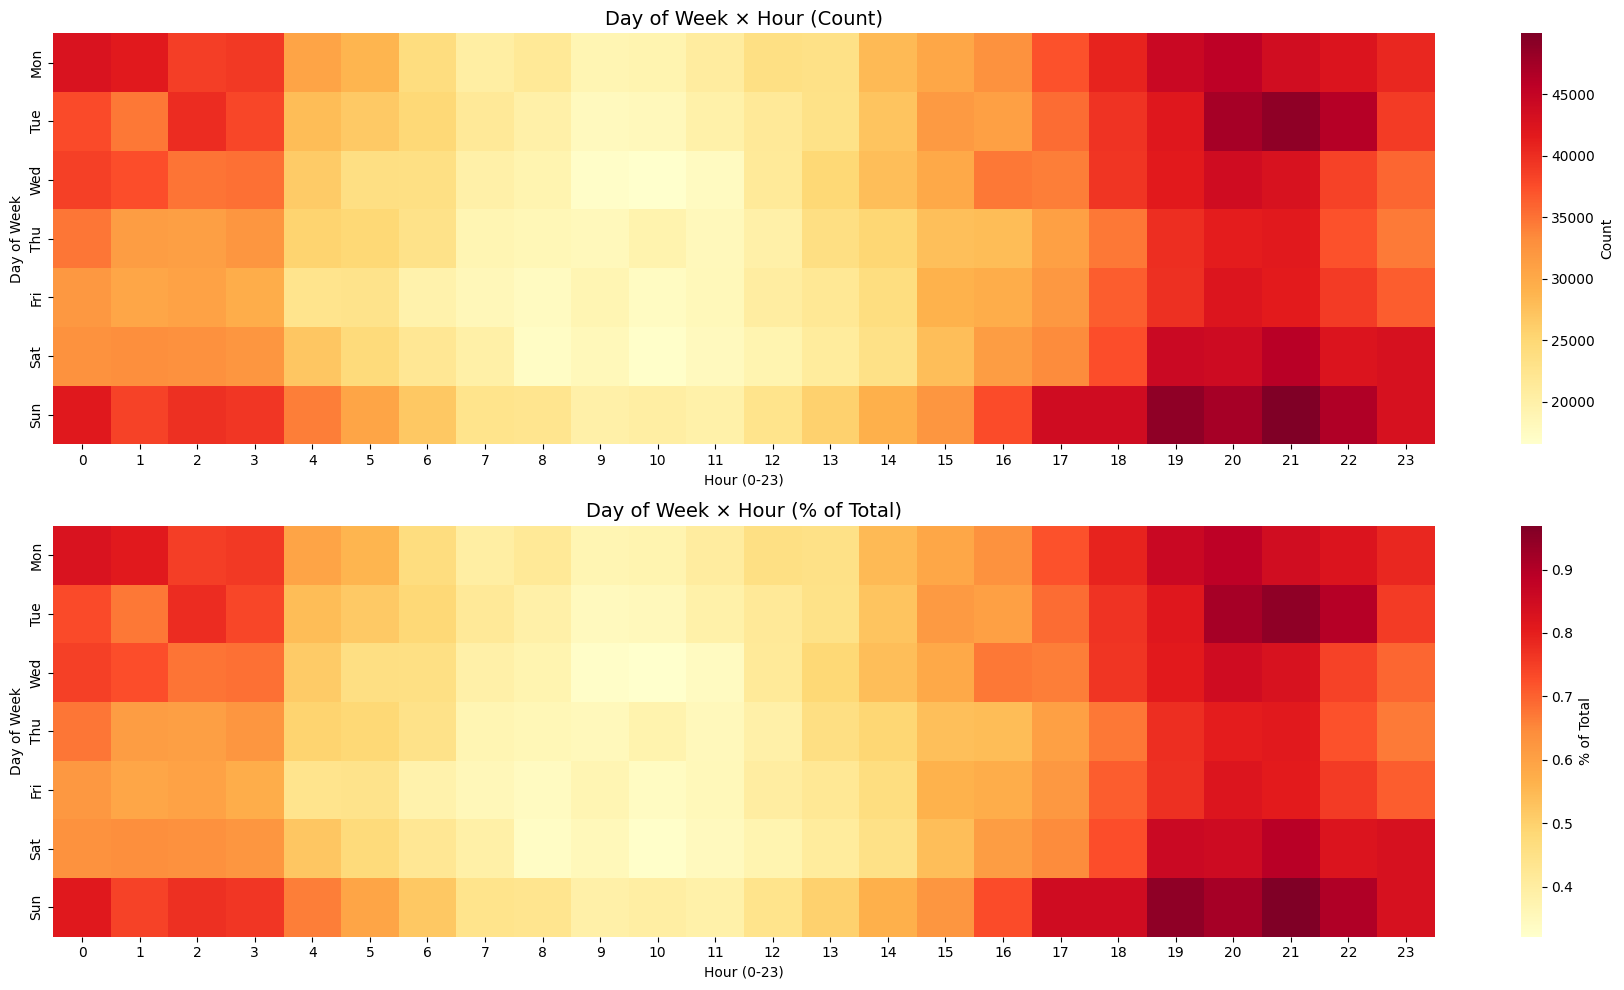

In [4]:
# 히트맵 시각화
fig, axes = plt.subplots(2, 1, figsize=(18, 10))

# 절대값 히트맵
sns.heatmap(dow_hour_crosstab, annot=False, fmt=',d', cmap='YlOrRd', ax=axes[0],
            cbar_kws={'label': 'Count'})
axes[0].set_title('Day of Week × Hour (Count)', fontsize=14)
axes[0].set_xlabel('Hour (0-23)')
axes[0].set_ylabel('Day of Week')

# 비율 히트맵
sns.heatmap(dow_hour_pct, annot=False, fmt='.2f', cmap='YlOrRd', ax=axes[1],
            cbar_kws={'label': '% of Total'})
axes[1].set_title('Day of Week × Hour (% of Total)', fontsize=14)
axes[1].set_xlabel('Hour (0-23)')
axes[1].set_ylabel('Day of Week')

plt.tight_layout()
plt.show()

In [5]:
# 인사이트 출력
print("=" * 60)
print("[요일 × 시간 인사이트]")
max_idx = dow_hour_crosstab.stack().idxmax()
min_idx = dow_hour_crosstab.stack().idxmin()
print(f"가장 많은 조합: {max_idx[0]} {max_idx[1]}시 ({dow_hour_crosstab.loc[max_idx[0], max_idx[1]]:,}건)")
print(f"가장 적은 조합: {min_idx[0]} {min_idx[1]}시 ({dow_hour_crosstab.loc[min_idx[0], min_idx[1]]:,}건)")

# 주말 vs 평일 비교
weekday_total = dow_hour_crosstab.loc[['Mon', 'Tue', 'Wed', 'Thu', 'Fri']].sum().sum()
weekend_total = dow_hour_crosstab.loc[['Sat', 'Sun']].sum().sum()
print(f"\n평일 총 상호작용: {weekday_total:,} ({weekday_total/(weekday_total+weekend_total)*100:.1f}%)")
print(f"주말 총 상호작용: {weekend_total:,} ({weekend_total/(weekday_total+weekend_total)*100:.1f}%)")
print(f"주말 일평균: {weekend_total/2:,.0f} vs 평일 일평균: {weekday_total/5:,.0f}")

# 피크 시간대 분석
print("\n[시간대별 상호작용 Top 5]")
hourly_total = dow_hour_crosstab.sum(axis=0).sort_values(ascending=False)
for i, (hour, count) in enumerate(hourly_total.head(5).items(), 1):
    print(f"  {i}. {hour}시: {count:,}건 ({count/dow_hour_crosstab.sum().sum()*100:.1f}%)")

[요일 × 시간 인사이트]
가장 많은 조합: Sun 21시 (49,940건)
가장 적은 조합: Wed 10시 (16,557건)

평일 총 상호작용: 3,618,953 (70.2%)
주말 총 상호작용: 1,535,518 (29.8%)
주말 일평균: 767,759 vs 평일 일평균: 723,791

[시간대별 상호작용 Top 5]
  1. 21시: 314,571건 (6.1%)
  2. 20시: 311,435건 (6.0%)
  3. 19시: 300,987건 (5.8%)
  4. 22시: 292,308건 (5.7%)
  5. 23시: 272,292건 (5.3%)


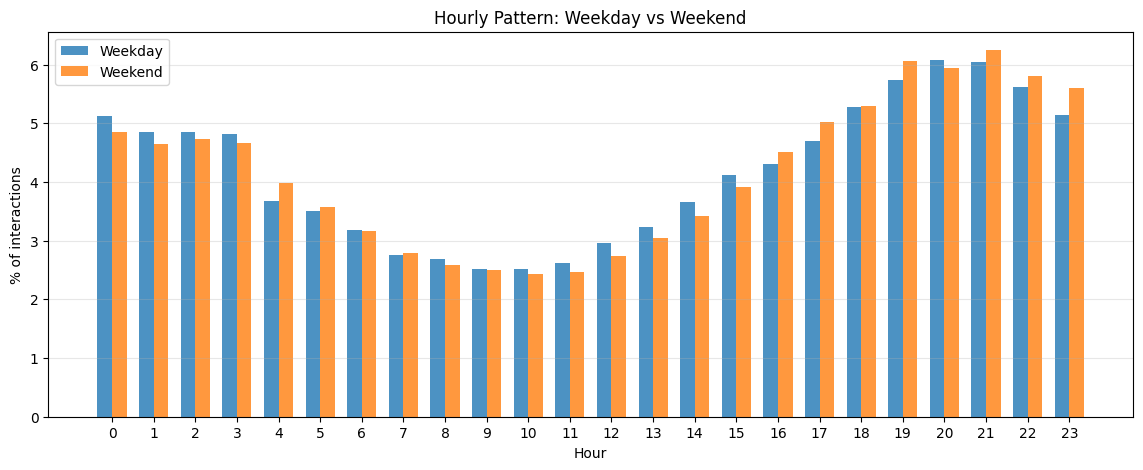

[평일 vs 주말 피크 시간]
평일 피크: 20시 (6.1%)
주말 피크: 21시 (6.2%)


In [6]:
# 평일 vs 주말 시간대별 패턴 비교
weekday_hourly = dow_hour_crosstab.loc[['Mon', 'Tue', 'Wed', 'Thu', 'Fri']].sum(axis=0)
weekend_hourly = dow_hour_crosstab.loc[['Sat', 'Sun']].sum(axis=0)

# 정규화 (각각의 총합 대비 비율)
weekday_hourly_pct = weekday_hourly / weekday_hourly.sum() * 100
weekend_hourly_pct = weekend_hourly / weekend_hourly.sum() * 100

plt.figure(figsize=(14, 5))
x = np.arange(24)
width = 0.35

plt.bar(x - width/2, weekday_hourly_pct.values, width, label='Weekday', alpha=0.8)
plt.bar(x + width/2, weekend_hourly_pct.values, width, label='Weekend', alpha=0.8)
plt.xlabel('Hour')
plt.ylabel('% of interactions')
plt.title('Hourly Pattern: Weekday vs Weekend')
plt.xticks(x)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

print("=" * 60)
print("[평일 vs 주말 피크 시간]")
print(f"평일 피크: {weekday_hourly_pct.idxmax()}시 ({weekday_hourly_pct.max():.1f}%)")
print(f"주말 피크: {weekend_hourly_pct.idxmax()}시 ({weekend_hourly_pct.max():.1f}%)")

### 1-2. 월 × 시간 히트맵 (계절성 분석)

In [7]:
# 월 × 시간 크로스탭
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

month_hour_crosstab = pd.crosstab(
    ratings['month'], 
    ratings['hour']
)
month_hour_crosstab.index = month_labels

# 각 월 내에서의 시간 비율 (행 기준 정규화)
month_hour_row_pct = month_hour_crosstab.div(month_hour_crosstab.sum(axis=1), axis=0) * 100

print("=" * 60)
print("[월 × 시간 상호작용 수]")
print(month_hour_crosstab)

[월 × 시간 상호작용 수]
hour     0      1      2      3      4      5      6      7      8      9   \
Jan   25988  24066  23644  23850  21117  16408  15567  12796  13816  10870   
Feb   24836  23417  20766  19959  18796  13519  13789  12116   9215   8882   
Mar   22475  20420  19017  19890  15528  16367  14365  10937  12601  12095   
Apr   18710  18993  19557  19739  15395  15027  11637  11491  11562  10964   
May   21026  19543  20279  18991  15324  15226  13802  13852  11386  10634   
Jun   20491  19453  21813  21510  15360  15371  12457  10625  11636  10723   
Jul   22403  21788  21676  21637  17526  17649  13787  12139  12761  12001   
Aug   18494  17494  18106  17282  13015  15063  12504  10790  10137   9454   
Sep   18229  17640  19284  18206  11430  14931  11995  11561   9655   9711   
Oct   22469  21639  19358  21696  13502  14289  13813  12286  10545  12195   
Nov   23394  21997  23683  22446  16476  13149  14279  10864  11109  10785   
Dec   21818  20828  21266  20454  20857  14743  

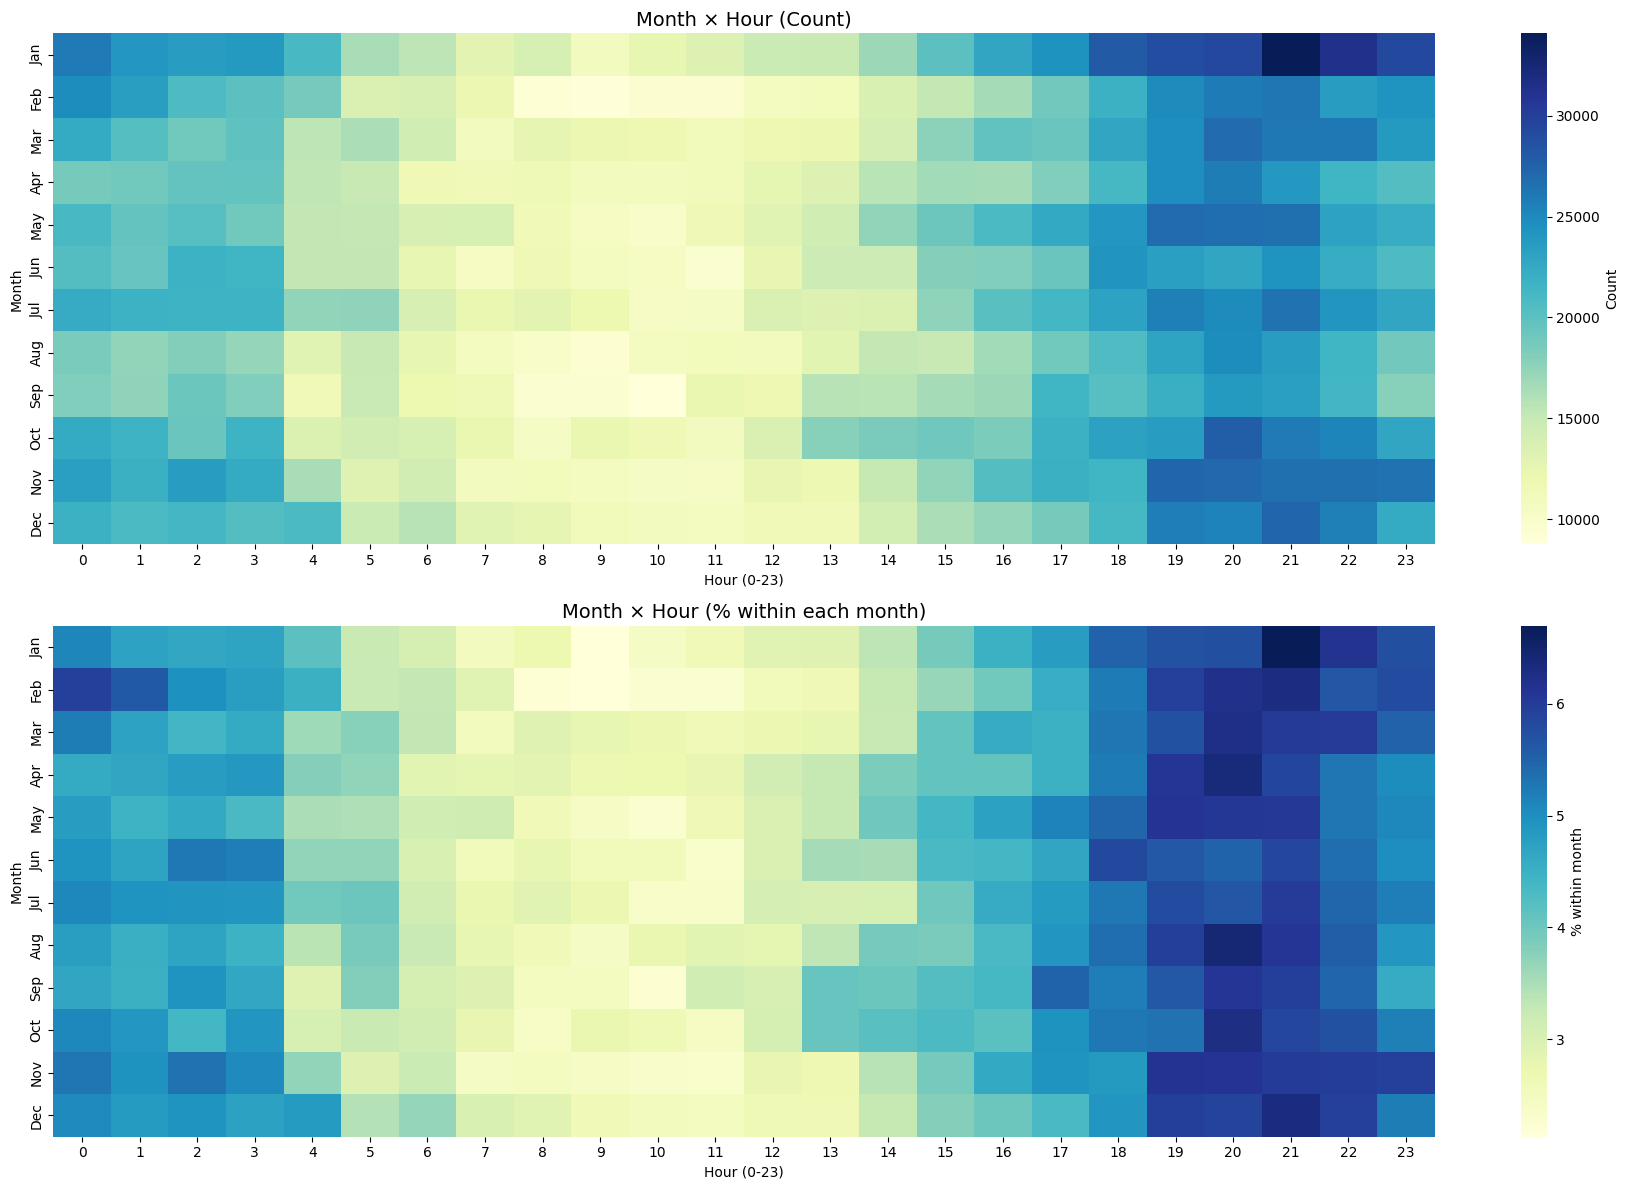

In [8]:
# 히트맵 시각화
fig, axes = plt.subplots(2, 1, figsize=(18, 12))

# 절대값 히트맵
sns.heatmap(month_hour_crosstab, annot=False, cmap='YlGnBu', ax=axes[0],
            cbar_kws={'label': 'Count'})
axes[0].set_title('Month × Hour (Count)', fontsize=14)
axes[0].set_xlabel('Hour (0-23)')
axes[0].set_ylabel('Month')

# 월별 시간 비율 히트맵 (계절에 따른 시간 패턴 변화 확인)
sns.heatmap(month_hour_row_pct, annot=False, cmap='YlGnBu', ax=axes[1],
            cbar_kws={'label': '% within month'})
axes[1].set_title('Month × Hour (% within each month)', fontsize=14)
axes[1].set_xlabel('Hour (0-23)')
axes[1].set_ylabel('Month')

plt.tight_layout()
plt.show()

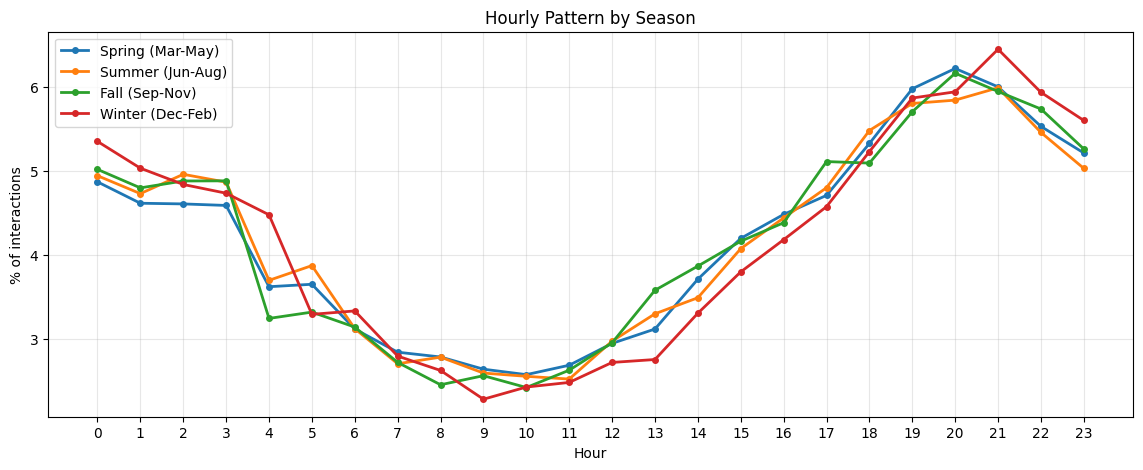

[계절별 피크 시간]
  Spring (Mar-May): 20시
  Summer (Jun-Aug): 21시
  Fall (Sep-Nov): 20시
  Winter (Dec-Feb): 21시


In [9]:
# 계절별 시간 패턴 비교
seasons = {
    'Spring (Mar-May)': ['Mar', 'Apr', 'May'],
    'Summer (Jun-Aug)': ['Jun', 'Jul', 'Aug'],
    'Fall (Sep-Nov)': ['Sep', 'Oct', 'Nov'],
    'Winter (Dec-Feb)': ['Dec', 'Jan', 'Feb']
}

plt.figure(figsize=(14, 5))
for season, months in seasons.items():
    season_hourly = month_hour_crosstab.loc[months].sum(axis=0)
    season_hourly_pct = season_hourly / season_hourly.sum() * 100
    plt.plot(range(24), season_hourly_pct.values, label=season, linewidth=2, marker='o', markersize=4)

plt.xlabel('Hour')
plt.ylabel('% of interactions')
plt.title('Hourly Pattern by Season')
plt.xticks(range(24))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 계절별 피크 시간
print("=" * 60)
print("[계절별 피크 시간]")
for season, months in seasons.items():
    season_hourly = month_hour_crosstab.loc[months].sum(axis=0)
    peak_hour = season_hourly.idxmax()
    print(f"  {season}: {peak_hour}시")

### 1-3. 연도-월 시계열 추세

In [10]:
# 연도-월 조합 생성
ratings['year_month'] = ratings['datetime'].dt.to_period('M')
year_month_counts = ratings.groupby('year_month').size()

print("=" * 60)
print("[연도-월별 상호작용 수]")
print(f"기간: {year_month_counts.index.min()} ~ {year_month_counts.index.max()}")
print(f"총 {len(year_month_counts)}개월")
print(f"\n월평균 상호작용: {year_month_counts.mean():,.0f}")
print(f"최소: {year_month_counts.min():,} ({year_month_counts.idxmin()})")
print(f"최대: {year_month_counts.max():,} ({year_month_counts.idxmax()})")

[연도-월별 상호작용 수]
기간: 2005-04 ~ 2015-03
총 120개월

월평균 상호작용: 42,954
최소: 17,756 (2014-09)
최대: 97,398 (2008-10)


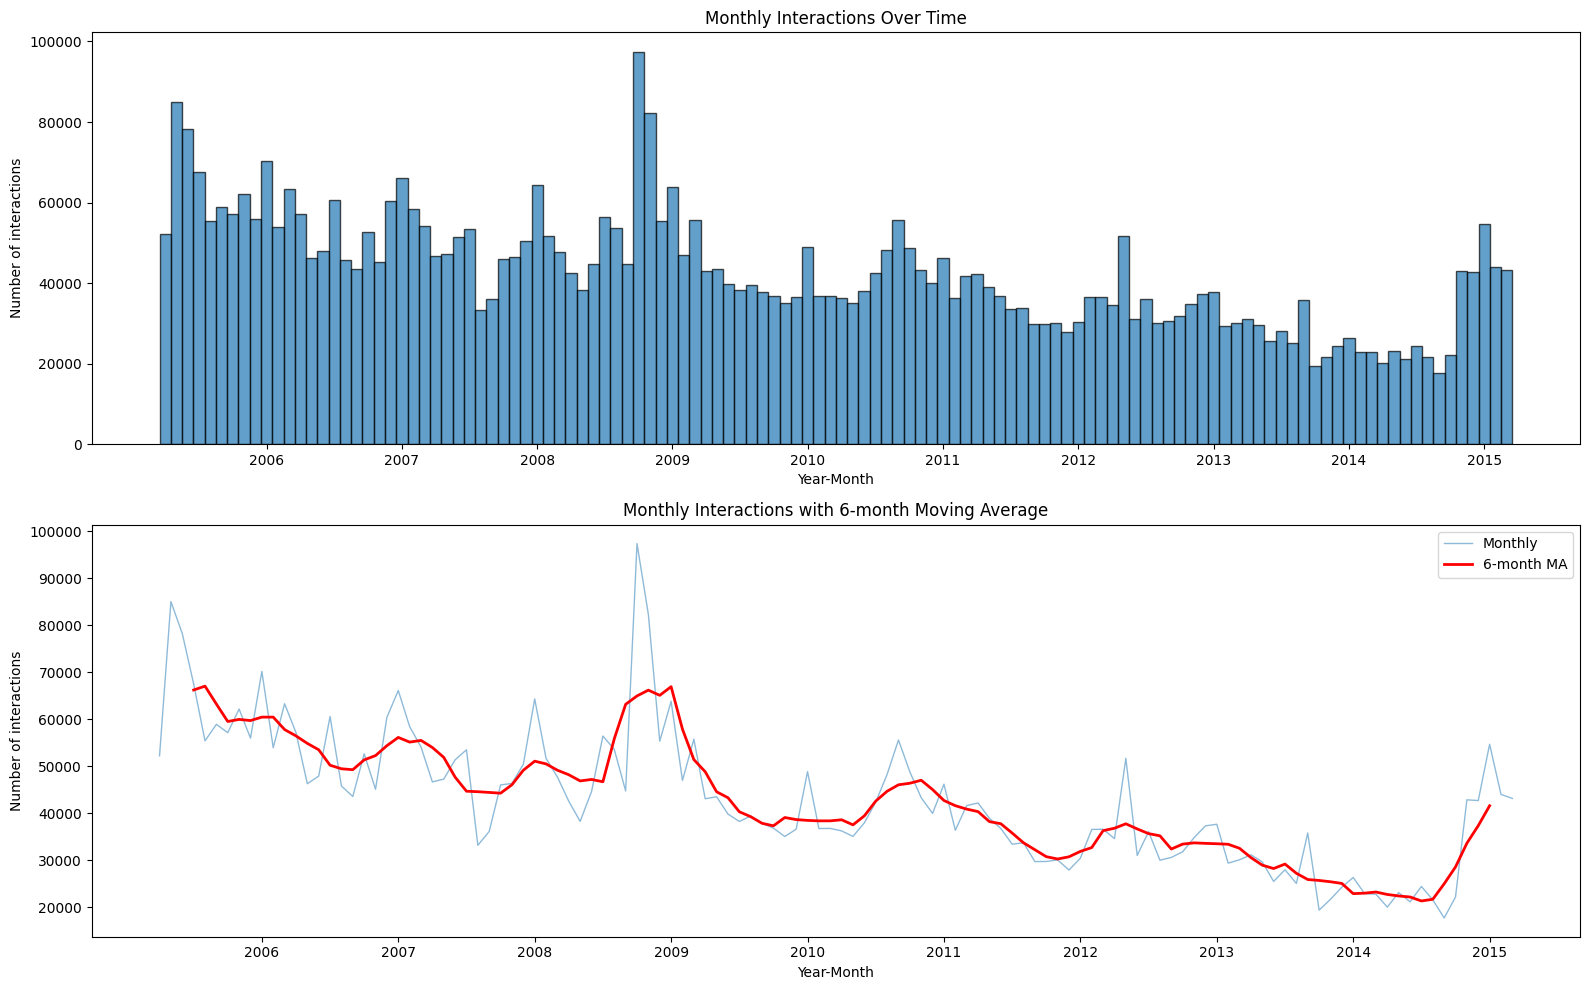

[연도별 월평균 상호작용]
  2005: 63,655 (부분 연도, 9개월)
  2006: 53,937
  2007: 49,162
  2008: 56,606
  2009: 43,114
  2010: 42,532
  2011: 35,592
  2012: 35,162
  2013: 28,176
  2014: 25,690
  2015: 47,312 (부분 연도, 3개월)


In [11]:
# 시계열 시각화
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# 바 차트
x_labels = [str(ym) for ym in year_month_counts.index]
axes[0].bar(range(len(year_month_counts)), year_month_counts.values, 
            edgecolor='black', alpha=0.7, width=1.0)
axes[0].set_xlabel('Year-Month')
axes[0].set_ylabel('Number of interactions')
axes[0].set_title('Monthly Interactions Over Time')

# x축 레이블 간소화 (연도 시작점만 표시)
tick_positions = [i for i, ym in enumerate(year_month_counts.index) if ym.month == 1]
tick_labels = [str(year_month_counts.index[i].year) for i in tick_positions]
axes[0].set_xticks(tick_positions)
axes[0].set_xticklabels(tick_labels)

# 이동평균 추가한 라인 차트
axes[1].plot(range(len(year_month_counts)), year_month_counts.values, 
             alpha=0.5, label='Monthly', linewidth=1)
# 6개월 이동평균
ma_6 = year_month_counts.rolling(window=6, center=True).mean()
axes[1].plot(range(len(ma_6)), ma_6.values, 
             color='red', label='6-month MA', linewidth=2)
axes[1].set_xlabel('Year-Month')
axes[1].set_ylabel('Number of interactions')
axes[1].set_title('Monthly Interactions with 6-month Moving Average')
axes[1].set_xticks(tick_positions)
axes[1].set_xticklabels(tick_labels)
axes[1].legend()

plt.tight_layout()
plt.show()

# 연도별 추세 요약
print("=" * 60)
print("[연도별 월평균 상호작용]")
for yr in sorted(ratings['year'].unique()):
    yr_data = ratings[ratings['year'] == yr]
    n_months = yr_data['month'].nunique()
    total = len(yr_data)
    avg = total / n_months
    if n_months < 12:
        print(f"  {yr}: {avg:,.0f} (부분 연도, {n_months}개월)")
    else:
        print(f"  {yr}: {avg:,.0f}")

---
## 2. Genre 조합 분석

### 2-1. 장르 Co-occurrence 히트맵

In [12]:
# 아이템별 장르 리스트 생성
item_genres = genres.groupby('item')['genre'].apply(list).to_dict()

# 장르 쌍 카운트
genre_pairs = Counter()
genre_single = Counter()

for item, genre_list in item_genres.items():
    # 단일 장르 카운트
    for g in genre_list:
        genre_single[g] += 1
    # 장르 쌍 카운트 (조합)
    if len(genre_list) >= 2:
        for pair in combinations(sorted(genre_list), 2):
            genre_pairs[pair] += 1

print("=" * 60)
print("[장르 Co-occurrence 분석]")
print(f"총 아이템 수: {len(item_genres)}")
print(f"2개 이상 장르를 가진 아이템: {sum(1 for g in item_genres.values() if len(g) >= 2)}")
print(f"고유 장르 쌍 수: {len(genre_pairs)}")

[장르 Co-occurrence 분석]
총 아이템 수: 6807
2개 이상 장르를 가진 아이템: 5051
고유 장르 쌍 수: 148


In [13]:
# Co-occurrence 행렬 생성
all_genres = sorted(genres['genre'].unique())
n_genres = len(all_genres)

# 대칭 행렬 생성
cooccur_matrix = pd.DataFrame(0, index=all_genres, columns=all_genres)

for (g1, g2), count in genre_pairs.items():
    cooccur_matrix.loc[g1, g2] = count
    cooccur_matrix.loc[g2, g1] = count

# 대각선에 단일 장르 카운트 (선택적)
for g, count in genre_single.items():
    cooccur_matrix.loc[g, g] = count

print("Co-occurrence Matrix (상위 10x10):")
print(cooccur_matrix.iloc[:10, :10])

Co-occurrence Matrix (상위 10x10):
             Action  Adventure  Animation  Children  Comedy  Crime  \
Action         1246        439         68        48     276    298   
Adventure       439        891        161       200     272     50   
Animation        68        161        355       203     161     15   
Children         48        200        203       432     229      9   
Comedy          276        272        161       229    2408    255   
Crime           298         50         15         9     255    924   
Documentary       3          2          2         1      38      3   
Drama           394        251         58        79     763    515   
Fantasy         142        235        123       146     205     16   
Film-Noir         5          2          2         0       3     55   

             Documentary  Drama  Fantasy  Film-Noir  
Action                 3    394      142          5  
Adventure              2    251      235          2  
Animation              2     58   

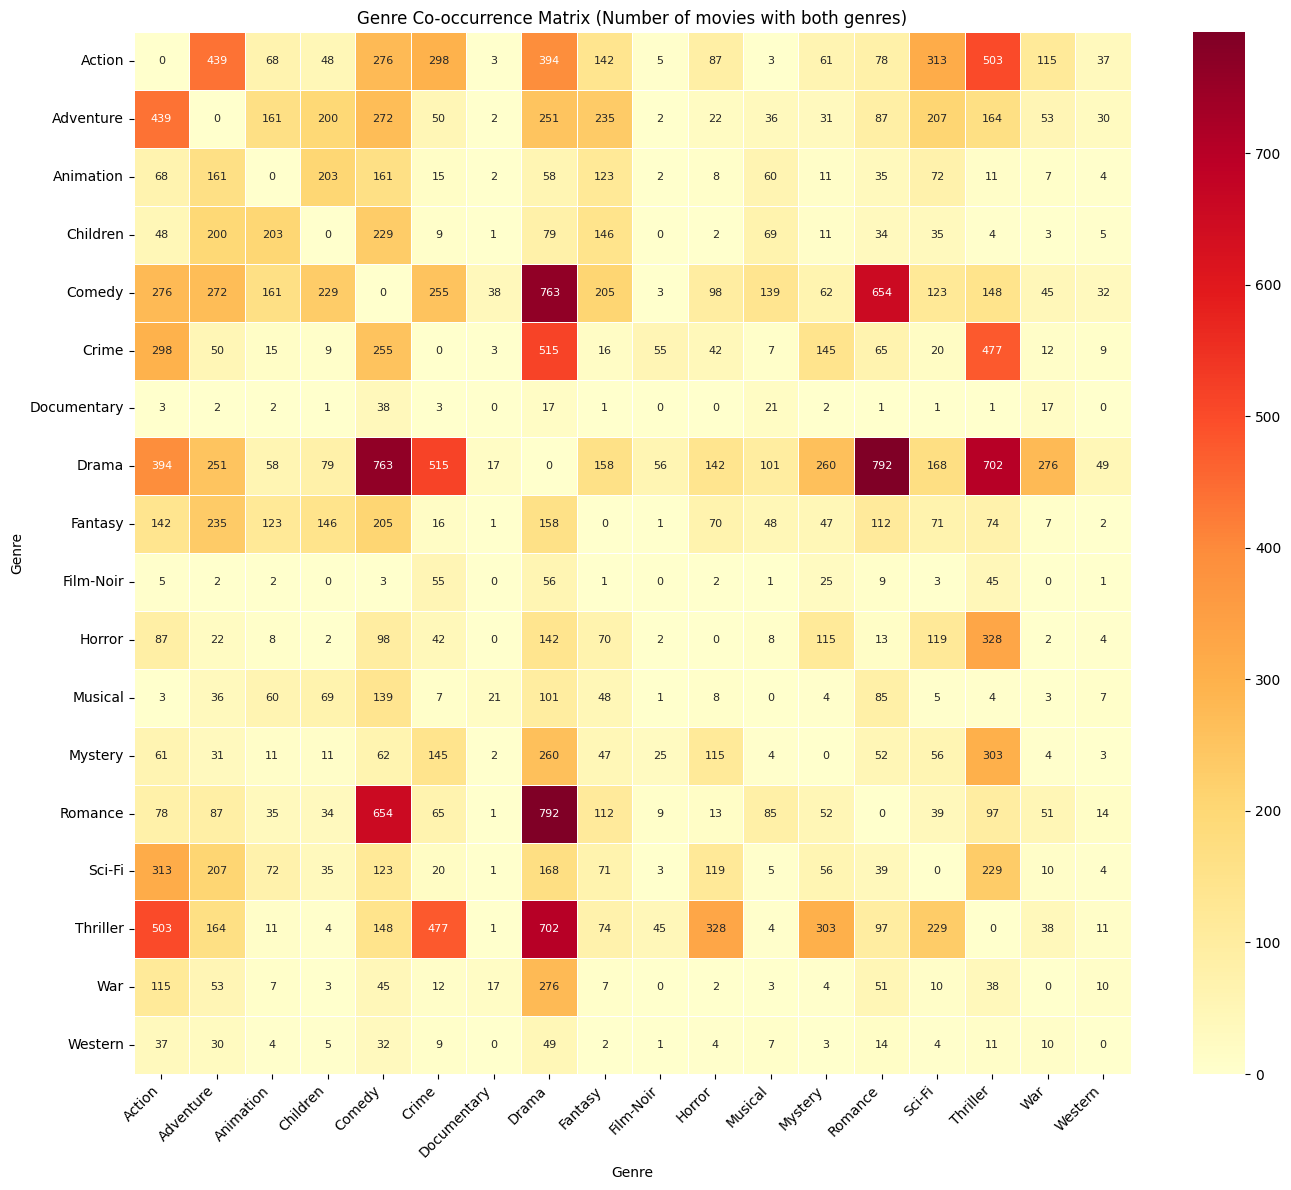

In [14]:
# 히트맵 시각화 (대각선 제외)
cooccur_no_diag = cooccur_matrix.copy()
np.fill_diagonal(cooccur_no_diag.values, 0)

plt.figure(figsize=(14, 12))
sns.heatmap(cooccur_no_diag, annot=True, fmt='d', cmap='YlOrRd', 
            linewidths=0.5, annot_kws={'size': 8})
plt.title('Genre Co-occurrence Matrix (Number of movies with both genres)')
plt.xlabel('Genre')
plt.ylabel('Genre')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

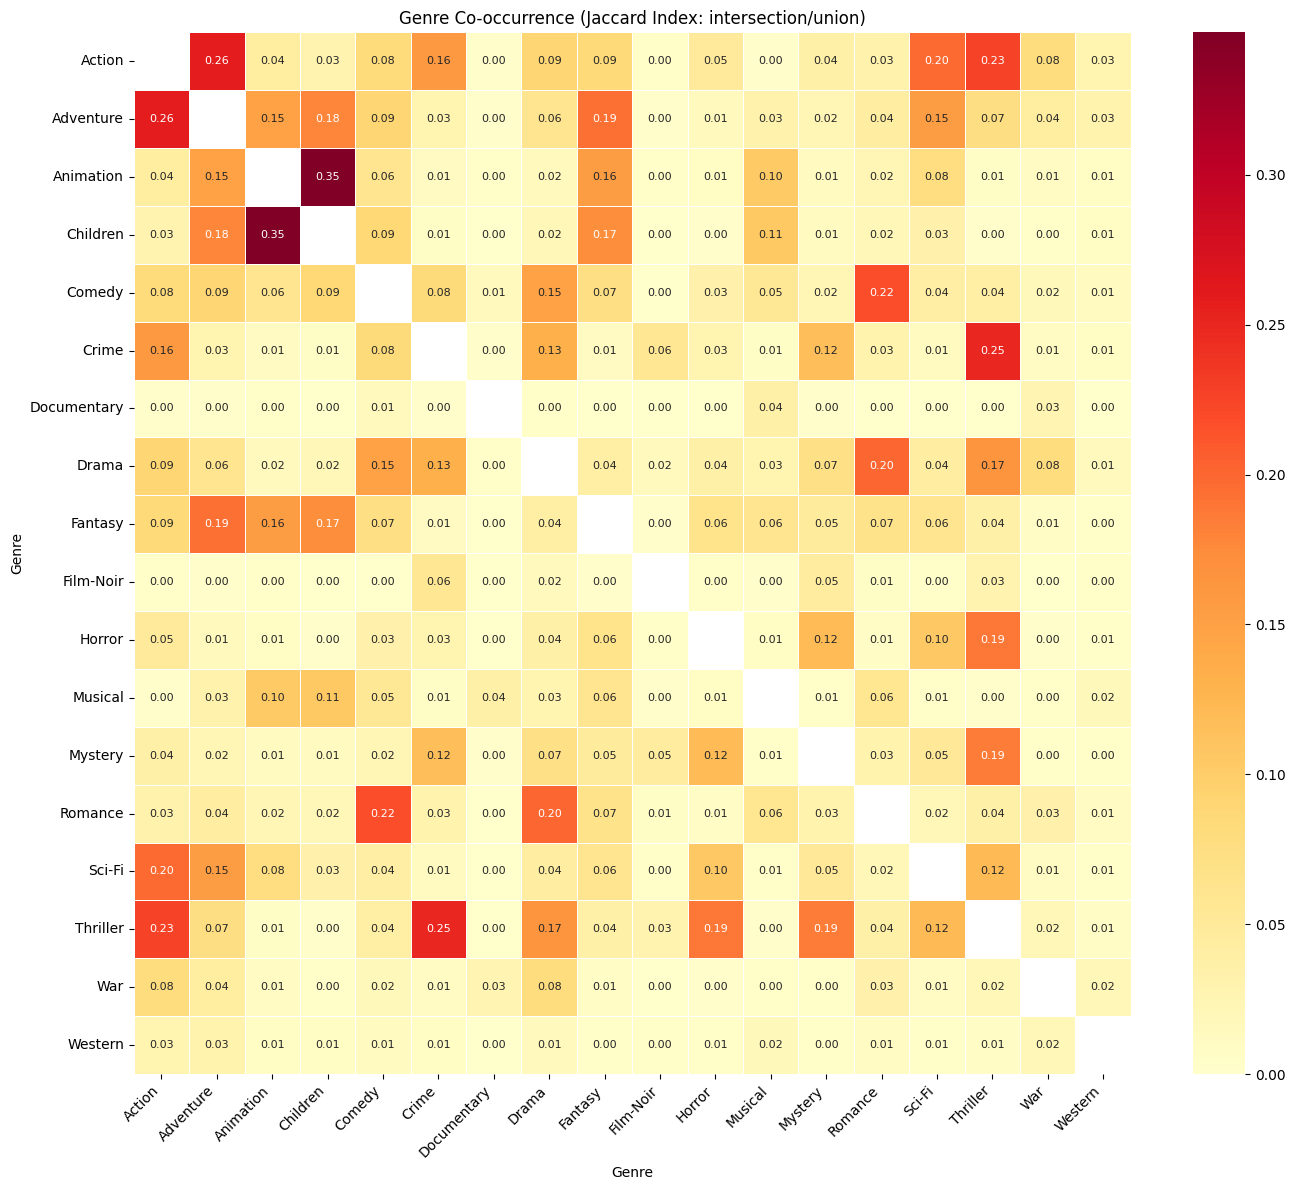

In [15]:
# 정규화된 Co-occurrence (Jaccard-like: 교집합 / 합집합)
# P(A∩B) / P(A∪B) = count(A,B) / (count(A) + count(B) - count(A,B))

cooccur_normalized = pd.DataFrame(0.0, index=all_genres, columns=all_genres)

for g1 in all_genres:
    for g2 in all_genres:
        if g1 == g2:
            cooccur_normalized.loc[g1, g2] = 1.0
        else:
            intersection = cooccur_matrix.loc[g1, g2]
            union = genre_single[g1] + genre_single[g2] - intersection
            if union > 0:
                cooccur_normalized.loc[g1, g2] = intersection / union

plt.figure(figsize=(14, 12))
mask = np.eye(len(all_genres), dtype=bool)  # 대각선 마스킹
sns.heatmap(cooccur_normalized, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, annot_kws={'size': 8}, mask=mask)
plt.title('Genre Co-occurrence (Jaccard Index: intersection/union)')
plt.xlabel('Genre')
plt.ylabel('Genre')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 2-2. 장르 조합 Top 20

In [16]:
# 장르 쌍 Top 20
top_pairs = genre_pairs.most_common(20)

print("=" * 60)
print("[장르 조합 Top 20]")
for i, ((g1, g2), count) in enumerate(top_pairs, 1):
    print(f"  {i:2d}. {g1} + {g2}: {count}개")

[장르 조합 Top 20]
   1. Drama + Romance: 792개
   2. Comedy + Drama: 763개
   3. Drama + Thriller: 702개
   4. Comedy + Romance: 654개
   5. Crime + Drama: 515개
   6. Action + Thriller: 503개
   7. Crime + Thriller: 477개
   8. Action + Adventure: 439개
   9. Action + Drama: 394개
  10. Horror + Thriller: 328개
  11. Action + Sci-Fi: 313개
  12. Mystery + Thriller: 303개
  13. Action + Crime: 298개
  14. Action + Comedy: 276개
  15. Drama + War: 276개
  16. Adventure + Comedy: 272개
  17. Drama + Mystery: 260개
  18. Comedy + Crime: 255개
  19. Adventure + Drama: 251개
  20. Adventure + Fantasy: 235개


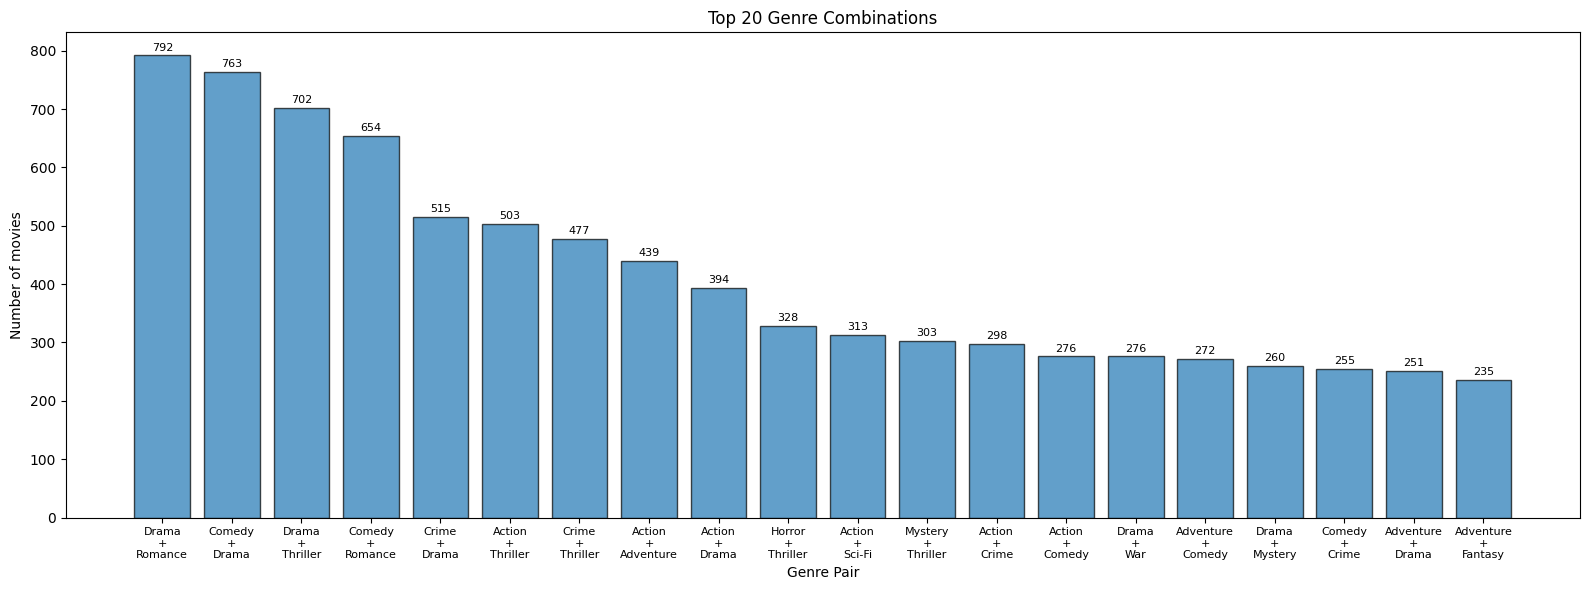

In [17]:
# 시각화
pair_labels = [f"{g1}\n+\n{g2}" for (g1, g2), _ in top_pairs]
pair_counts = [count for _, count in top_pairs]

plt.figure(figsize=(16, 6))
bars = plt.bar(range(len(top_pairs)), pair_counts, edgecolor='black', alpha=0.7)
plt.xlabel('Genre Pair')
plt.ylabel('Number of movies')
plt.title('Top 20 Genre Combinations')
plt.xticks(range(len(top_pairs)), pair_labels, fontsize=8)

# 값 표시
for bar, count in zip(bars, pair_counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
             str(count), ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

In [18]:
# 3개 이상 장르 조합 분석
genre_triplets = Counter()
for item, genre_list in item_genres.items():
    if len(genre_list) >= 3:
        for triplet in combinations(sorted(genre_list), 3):
            genre_triplets[triplet] += 1

print("=" * 60)
print("[3개 장르 조합 Top 10]")
for i, (triplet, count) in enumerate(genre_triplets.most_common(10), 1):
    print(f"  {i:2d}. {' + '.join(triplet)}: {count}개")

[3개 장르 조합 Top 10]
   1. Comedy + Drama + Romance: 282개
   2. Crime + Drama + Thriller: 264개
   3. Action + Crime + Thriller: 183개
   4. Action + Drama + Thriller: 167개
   5. Drama + Mystery + Thriller: 156개
   6. Action + Adventure + Sci-Fi: 136개
   7. Action + Adventure + Thriller: 130개
   8. Action + Sci-Fi + Thriller: 125개
   9. Action + Crime + Drama: 119개
  10. Adventure + Animation + Children: 111개


---
## 3. 개봉연도 vs 시청연도 Gap 분석

In [19]:
# ratings에 개봉연도 조인
ratings_with_release = ratings.merge(years, on='item', how='left')
ratings_with_release = ratings_with_release.rename(columns={'year_x': 'watch_year', 'year_y': 'release_year'})

# Gap 계산 (시청연도 - 개봉연도)
ratings_with_release['gap'] = ratings_with_release['watch_year'] - ratings_with_release['release_year']

# 결측치 확인
print("=" * 60)
print("[개봉연도 정보 현황]")
print(f"전체 상호작용: {len(ratings_with_release):,}")
print(f"개봉연도 있음: {ratings_with_release['release_year'].notna().sum():,}")
print(f"개봉연도 없음: {ratings_with_release['release_year'].isna().sum():,}")

# 결측치 제외
valid_gap = ratings_with_release[ratings_with_release['gap'].notna()]['gap']

print(f"\n[Gap 통계] (시청연도 - 개봉연도)")
print(f"평균: {valid_gap.mean():.1f}년")
print(f"중앙값: {valid_gap.median():.0f}년")
print(f"표준편차: {valid_gap.std():.1f}년")
print(f"최소: {valid_gap.min():.0f}년 (미래 개봉작 시청?)")
print(f"최대: {valid_gap.max():.0f}년")

[개봉연도 정보 현황]
전체 상호작용: 5,154,471
개봉연도 있음: 5,152,639
개봉연도 없음: 1,832

[Gap 통계] (시청연도 - 개봉연도)
평균: 15.2년
중앙값: 11년
표준편차: 15.2년
최소: -1년 (미래 개봉작 시청?)
최대: 93년


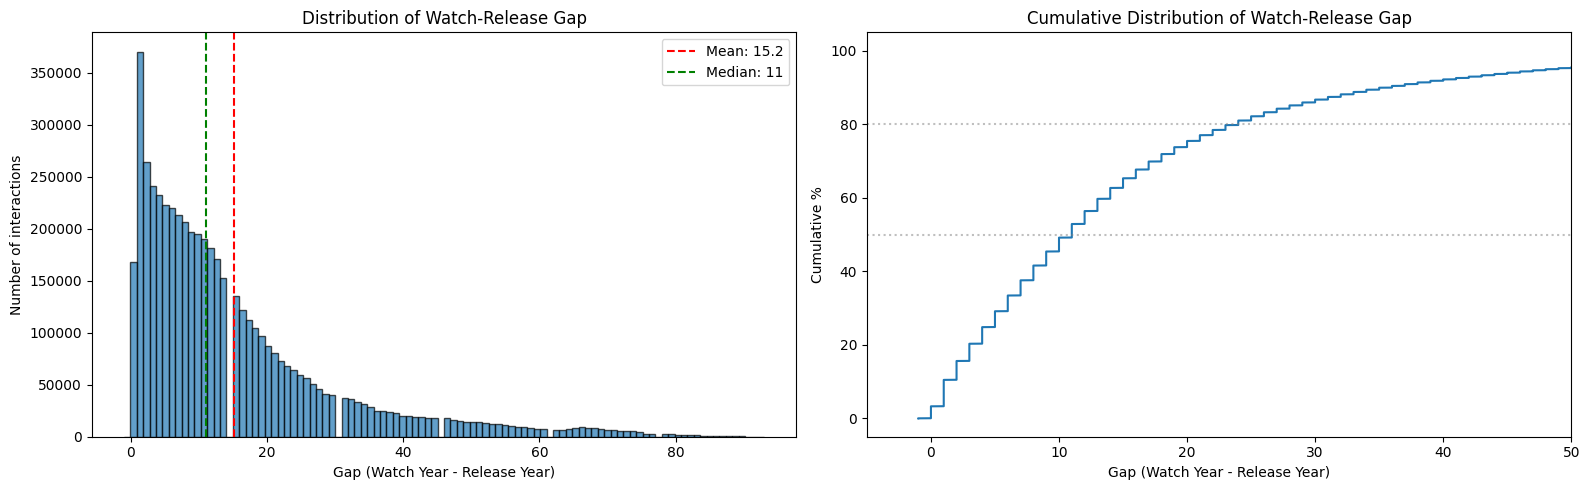

In [20]:
# Gap 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 히스토그램
axes[0].hist(valid_gap, bins=100, edgecolor='black', alpha=0.7)
axes[0].axvline(valid_gap.mean(), color='red', linestyle='--', label=f'Mean: {valid_gap.mean():.1f}')
axes[0].axvline(valid_gap.median(), color='green', linestyle='--', label=f'Median: {valid_gap.median():.0f}')
axes[0].set_xlabel('Gap (Watch Year - Release Year)')
axes[0].set_ylabel('Number of interactions')
axes[0].set_title('Distribution of Watch-Release Gap')
axes[0].legend()

# 누적 분포
gap_sorted = np.sort(valid_gap)
cumulative = np.arange(1, len(gap_sorted) + 1) / len(gap_sorted) * 100
axes[1].plot(gap_sorted, cumulative)
axes[1].axhline(50, color='gray', linestyle=':', alpha=0.5)
axes[1].axhline(80, color='gray', linestyle=':', alpha=0.5)
axes[1].set_xlabel('Gap (Watch Year - Release Year)')
axes[1].set_ylabel('Cumulative %')
axes[1].set_title('Cumulative Distribution of Watch-Release Gap')
axes[1].set_xlim(-5, 50)

plt.tight_layout()
plt.show()

In [21]:
# Gap 구간별 분석
print("=" * 60)
print("[Gap 구간별 상호작용 비율]")

gap_bins = [
    ('개봉 당해 (0년)', valid_gap == 0),
    ('1년 이내', (valid_gap >= 0) & (valid_gap <= 1)),
    ('3년 이내', (valid_gap >= 0) & (valid_gap <= 3)),
    ('5년 이내', (valid_gap >= 0) & (valid_gap <= 5)),
    ('10년 이내', (valid_gap >= 0) & (valid_gap <= 10)),
    ('10년 초과', valid_gap > 10),
    ('20년 초과', valid_gap > 20),
    ('50년 초과', valid_gap > 50),
]

for label, mask in gap_bins:
    count = mask.sum()
    pct = count / len(valid_gap) * 100
    print(f"  {label}: {count:,} ({pct:.1f}%)")

[Gap 구간별 상호작용 비율]
  개봉 당해 (0년): 168,457 (3.3%)
  1년 이내: 539,007 (10.5%)
  3년 이내: 1,045,426 (20.3%)
  5년 이내: 1,500,946 (29.1%)
  10년 이내: 2,532,821 (49.2%)
  10년 초과: 2,619,815 (50.8%)
  20년 초과: 1,265,039 (24.6%)
  50년 초과: 230,382 (4.5%)


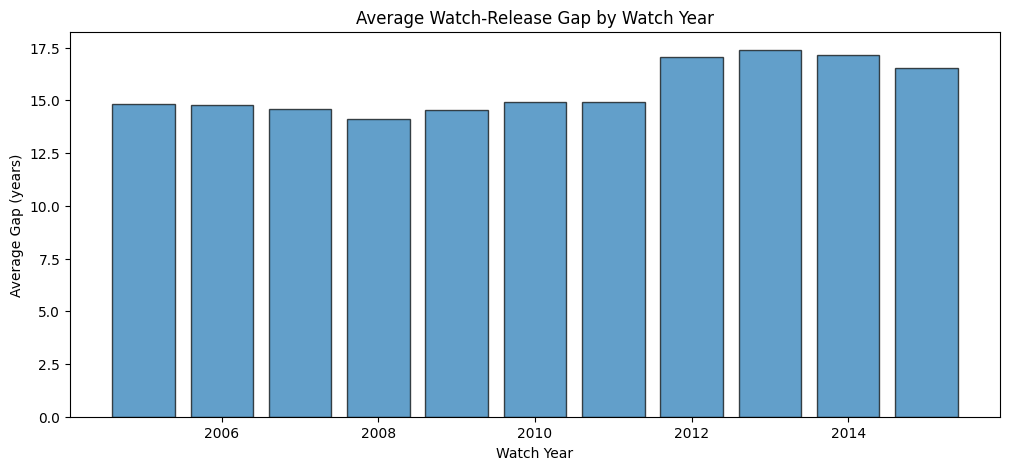

[시청연도별 평균 Gap]
  2005: 14.8년
  2006: 14.8년
  2007: 14.6년
  2008: 14.1년
  2009: 14.6년
  2010: 14.9년
  2011: 14.9년
  2012: 17.0년
  2013: 17.4년
  2014: 17.1년
  2015: 16.5년


In [22]:
# 시청연도별 평균 Gap 변화
avg_gap_by_watch_year = ratings_with_release.groupby('watch_year')['gap'].mean()

plt.figure(figsize=(12, 5))
plt.bar(avg_gap_by_watch_year.index, avg_gap_by_watch_year.values, 
        edgecolor='black', alpha=0.7)
plt.xlabel('Watch Year')
plt.ylabel('Average Gap (years)')
plt.title('Average Watch-Release Gap by Watch Year')
plt.show()

print("=" * 60)
print("[시청연도별 평균 Gap]")
for year, gap in avg_gap_by_watch_year.items():
    print(f"  {year}: {gap:.1f}년")

---
## 4. 요약

In [23]:
print("=" * 60)
print("[Step 2-1 단변량 내 조합 분석 요약]")
print("=" * 60)

print("\n1. 요일 × 시간 (1시간 단위)")
max_idx = dow_hour_crosstab.stack().idxmax()
print(f"   - 가장 활발: {max_idx[0]} {max_idx[1]}시")
print(f"   - 주말 일평균이 평일 대비 높음 (주말: {weekend_total/2:,.0f} vs 평일: {weekday_total/5:,.0f})")
print(f"   - 평일 피크: {weekday_hourly_pct.idxmax()}시, 주말 피크: {weekend_hourly_pct.idxmax()}시")

print("\n2. 월 × 시간 (계절성)")
print(f"   - 계절별 시간 패턴 차이 확인 필요 (히트맵 참조)")

print("\n3. 연도-월 추세")
print(f"   - 2005년 시작, 2008년 피크 후 점진적 감소")
print(f"   - 2015년 3월까지만 데이터 존재")

print("\n4. 장르 Co-occurrence")
top3_pairs = genre_pairs.most_common(3)
print(f"   - Top 1: {top3_pairs[0][0][0]} + {top3_pairs[0][0][1]} ({top3_pairs[0][1]}개)")
print(f"   - Top 2: {top3_pairs[1][0][0]} + {top3_pairs[1][0][1]} ({top3_pairs[1][1]}개)")
print(f"   - Top 3: {top3_pairs[2][0][0]} + {top3_pairs[2][0][1]} ({top3_pairs[2][1]}개)")

print("\n5. 개봉-시청 Gap")
print(f"   - 평균 Gap: {valid_gap.mean():.1f}년")
print(f"   - 중앙값 Gap: {valid_gap.median():.0f}년")
print(f"   - 10년 이내 시청 비율: {((valid_gap >= 0) & (valid_gap <= 10)).sum() / len(valid_gap) * 100:.1f}%")
print(f"   - 시간이 지날수록 평균 Gap 증가 (더 오래된 영화도 시청)")

[Step 2-1 단변량 내 조합 분석 요약]

1. 요일 × 시간 (1시간 단위)
   - 가장 활발: Sun 21시
   - 주말 일평균이 평일 대비 높음 (주말: 767,759 vs 평일: 723,791)
   - 평일 피크: 20시, 주말 피크: 21시

2. 월 × 시간 (계절성)
   - 계절별 시간 패턴 차이 확인 필요 (히트맵 참조)

3. 연도-월 추세
   - 2005년 시작, 2008년 피크 후 점진적 감소
   - 2015년 3월까지만 데이터 존재

4. 장르 Co-occurrence
   - Top 1: Drama + Romance (792개)
   - Top 2: Comedy + Drama (763개)
   - Top 3: Drama + Thriller (702개)

5. 개봉-시청 Gap
   - 평균 Gap: 15.2년
   - 중앙값 Gap: 11년
   - 10년 이내 시청 비율: 49.2%
   - 시간이 지날수록 평균 Gap 증가 (더 오래된 영화도 시청)
